# Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# load datasets

In [2]:
raw_round = pd.read_csv("afl_players_round_by_round_stats_raw.csv")
merged_players = pd.read_csv("merged_players.csv")

# Initial Inspection

In [3]:
raw_round.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,NaN,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,NaN,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,NaN,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,NaN,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,NaN,-25


In [4]:
merged_players.head()

,player_id,player_name,player_full_name,first_name,last_name,born_date,debut_date,debut_age,last_date,last_age,...,avg_contested_possessions,avg_uncontested_possessions,avg_contested_marks,avg_marks_inside_50,avg_one_percenters,avg_bounces,avg_goal_assists,avg_score,avg_fantasy_points,avg_percentage_played
0,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,6.7,6.7,0.3,1.7,4.3,0.0,0.3,6.7,92.7,84.3
1,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,2.0,3.0,1.0,1.0,5.0,0.0,0.0,1.0,61.0,81.0
2,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,6.0,8.0,0.0,1.0,3.0,0.0,0.0,6.0,74.0,83.0
3,43261,Ryan Abbott,Ryan_Abbott,Ryan,Abbott,1991-06-25,2018-08-02,27,2020-09-05,29,...,0.0,3.0,0.0,1.0,0.0,0.0,0.0,6.0,22.0,54.0
4,43262,Gary Ablett,Gary_Ablett1,Gary,Ablett,1984-05-14,2002-03-30,17,2020-10-24,36,...,5.7,3.0,0.3,0.3,1.0,0.2,0.0,5.3,36.9,NaN


In [5]:
raw_round.info()

<class 'pandas.DataFrame'>
RangeIndex: 274089 entries, 0 to 274088
Data columns (total 36 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274089 non-null  int64  
 1   team                       274089 non-null  str    
 2   year                       274089 non-null  int64  
 3   career_game_count          274089 non-null  int64  
 4   opponent                   274089 non-null  str    
 5   round                      274089 non-null  str    
 6   result                     274089 non-null  str    
 7   jersey_num                 274089 non-null  int64  
 8   kicks                      272789 non-null  float64
 9   marks                      266038 non-null  float64
 10  handballs                  269656 non-null  float64
 11  disposals                  265636 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    192996 non-nu

In [6]:
merged_players.info()

<class 'pandas.DataFrame'>
RangeIndex: 25072 entries, 0 to 25071
Data columns (total 69 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   player_id                    25072 non-null  int64  
 1   player_name                  25072 non-null  str    
 2   player_full_name             25072 non-null  str    
 3   first_name                   25072 non-null  str    
 4   last_name                    25072 non-null  str    
 5   born_date                    25072 non-null  str    
 6   debut_date                   25072 non-null  str    
 7   debut_age                    25072 non-null  int64  
 8   last_date                    25072 non-null  str    
 9   last_age                     25072 non-null  int64  
 10  height                       25072 non-null  int64  
 11  weight                       25072 non-null  int64  
 12  profile_pic                  5065 non-null   str    
 13  player_link                

In [7]:
list(raw_round.columns)

['id',
 'team',
 'year',
 'career_game_count',
 'opponent',
 'round',
 'result',
 'jersey_num',
 'kicks',
 'marks',
 'handballs',
 'disposals',
 'goals',
 'behinds',
 'hit_outs',
 'tackles',
 'rebound_50s',
 'inside_50s',
 'clearances',
 'clangers',
 'free_kicks_for',
 'free_kicks_against',
 'brownlow_votes',
 'contested_possessions',
 'uncontested_possessions',
 'contested_marks',
 'marks_inside_50',
 'one_percenters',
 'bounces',
 'goal_assist',
 'percentage_of_game_played',
 'player_id',
 'match_date',
 'fantasy_points',
 'score',
 'margin']

In [8]:
list(merged_players.columns)

['player_id',
 'player_name',
 'player_full_name',
 'first_name',
 'last_name',
 'born_date',
 'debut_date',
 'debut_age',
 'last_date',
 'last_age',
 'height',
 'weight',
 'profile_pic',
 'player_link',
 'player_common_names',
 'player_teams',
 'year',
 'team',
 'is_finals',
 'games_played',
 'kicks',
 'marks',
 'handballs',
 'disposals',
 'goals',
 'behinds',
 'hit_outs',
 'tackles',
 'rebound_50s',
 'inside_50s',
 'clearances',
 'clangers',
 'free_kicks_for',
 'free_kicks_against',
 'brownlow_votes',
 'contested_possessions',
 'uncontested_possessions',
 'contested_marks',
 'marks_inside_50',
 'one_percenters',
 'bounces',
 'goal_assists',
 'total_score',
 'total_fantasy_points',
 'total_percentage_played',
 'avg_kicks',
 'avg_marks',
 'avg_handballs',
 'avg_disposals',
 'avg_goals',
 'avg_behinds',
 'avg_hit_outs',
 'avg_tackles',
 'avg_rebound_50s',
 'avg_inside_50s',
 'avg_clearances',
 'avg_clangers',
 'avg_free_kicks_for',
 'avg_free_kicks_against',
 'avg_contested_possessions'

In [9]:
raw_round.shape

(274089, 36)

In [10]:
merged_players.shape

(25072, 69)

In [11]:
raw_round.describe(include="all")

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,score,margin
count,274089.000000,274089,274089.000000,274089.000000,274089,274089,274089,274089.000000,272789.000000,266038.000000,...,182711.000000,213943.000000,176746.000000,170489.000000,204407.000000,274089.000000,274089,274089.000000,0.0,274089.000000
unique,NaN,20,NaN,NaN,20,30,3,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3276,NaN,NaN,NaN
top,NaN,Geelong Cats,NaN,NaN,Geelong Cats,18,W,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,2015-09-05,NaN,NaN,NaN
freq,NaN,16903,NaN,NaN,16831,11909,136266,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,270,NaN,NaN,NaN
mean,317627.891590,NaN,2010.140524,90.230786,NaN,NaN,NaN,20.045664,9.202508,4.078474,...,0.713657,2.212019,0.610707,0.453478,81.060815,44786.577312,NaN,65.244187,NaN,0.164669
std,238902.057585,NaN,9.443820,72.632905,NaN,NaN,NaN,12.657641,4.709571,2.550794,...,1.152437,2.163776,1.218281,0.707634,14.821722,818.523942,NaN,28.110251,NaN,43.620652
min,1.000000,NaN,1983.000000,1.000000,NaN,NaN,NaN,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,43260.000000,NaN,-10.000000,NaN,-186.000000
25%,72923.000000,NaN,2002.000000,31.000000,NaN,NaN,NaN,9.000000,6.000000,2.000000,...,0.000000,1.000000,0.000000,0.000000,77.000000,44077.000000,NaN,45.000000,NaN,-29.000000
50%,397686.000000,NaN,2011.000000,73.000000,NaN,NaN,NaN,19.000000,9.000000,4.000000,...,0.000000,2.000000,0.000000,0.000000,84.000000,44856.000000,NaN,64.000000,NaN,0.000000
75%,551104.000000,NaN,2018.000000,135.000000,NaN,NaN,NaN,30.000000,12.000000,6.000000,...,1.000000,3.000000,1.000000,1.000000,90.000000,45542.000000,NaN,84.000000,NaN,29.000000


##################################################################################

# Data Quality Validation

In [12]:
raw_round.isna().sum()

id                                0
team                              0
year                              0
career_game_count                 0
opponent                          0
round                             0
result                            0
jersey_num                        0
kicks                          1300
marks                          8051
handballs                      4433
disposals                      8453
goals                         74737
behinds                       81093
hit_outs                      96629
tackles                       28682
rebound_50s                   62856
inside_50s                    46574
clearances                    63919
clangers                      49965
free_kicks_for                53842
free_kicks_against            53275
brownlow_votes               110481
contested_possessions         38826
uncontested_possessions       37998
contested_marks               90677
marks_inside_50               91378
one_percenters              

In [13]:
raw_round.duplicated().sum()

np.int64(10)

# Cleaning the "afl_players_round_by_round_stats_raw.csv" dataset

In [14]:
# dropped "score" column as it was completely empty
raw_round = raw_round.drop(columns="score")

In [15]:
list(raw_round.columns)

['id',
 'team',
 'year',
 'career_game_count',
 'opponent',
 'round',
 'result',
 'jersey_num',
 'kicks',
 'marks',
 'handballs',
 'disposals',
 'goals',
 'behinds',
 'hit_outs',
 'tackles',
 'rebound_50s',
 'inside_50s',
 'clearances',
 'clangers',
 'free_kicks_for',
 'free_kicks_against',
 'brownlow_votes',
 'contested_possessions',
 'uncontested_possessions',
 'contested_marks',
 'marks_inside_50',
 'one_percenters',
 'bounces',
 'goal_assist',
 'percentage_of_game_played',
 'player_id',
 'match_date',
 'fantasy_points',
 'margin']

In [16]:
# dropped duplicated rows (where every column represent exactly the same data)
raw_round=raw_round.drop_duplicates()

In [17]:
print(raw_round.duplicated().sum())

0


In [18]:
raw_round.info()

<class 'pandas.DataFrame'>
Index: 274079 entries, 0 to 274088
Data columns (total 35 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   id                         274079 non-null  int64  
 1   team                       274079 non-null  str    
 2   year                       274079 non-null  int64  
 3   career_game_count          274079 non-null  int64  
 4   opponent                   274079 non-null  str    
 5   round                      274079 non-null  str    
 6   result                     274079 non-null  str    
 7   jersey_num                 274079 non-null  int64  
 8   kicks                      272780 non-null  float64
 9   marks                      266031 non-null  float64
 10  handballs                  269649 non-null  float64
 11  disposals                  265629 non-null  float64
 12  goals                      199352 non-null  float64
 13  behinds                    192996 non-null  f

In [19]:
raw_round["id"].nunique()

274079

In [20]:
len(raw_round)

274079

In [21]:
# checking if "round" column has unique values
raw_round["round"].unique()

<StringArray>
['21',  '1', '10',  '2', '20', '22',  '8', '11',  '9', 'SF', 'PF', '16', 'EF',
 'QF', '12',  '3', '13', 'GF', '15', '14', '17', '18', '19',  '0', '23',  '4',
  '5',  '6',  '7', '24']
Length: 30, dtype: str

In [22]:
raw_round[raw_round["round"]=="0"]

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,margin
3762,603710,Sydney Swans,2024,68,Melbourne Demons,0,W,21,16.0,2.0,...,NaN,NaN,2.0,NaN,NaN,89.0,43953,2024-03-07,69,22
5462,605182,Collingwood Magpies,2024,227,Greater Western Sydney Giants,0,L,25,9.0,2.0,...,NaN,NaN,2.0,NaN,1.0,85.0,43641,2024-03-09,75,-32
5479,605205,Collingwood Magpies,2025,250,Greater Western Sydney Giants,0,L,25,11.0,7.0,...,NaN,NaN,3.0,NaN,NaN,85.0,43641,2025-03-09,77,-52
7045,606288,Melbourne Demons,2024,161,Sydney Swans,0,L,8,9.0,6.0,...,NaN,NaN,5.0,NaN,NaN,100.0,44278,2024-03-07,48,-22
7438,610612,Hawthorn Hawks,2025,85,Sydney Swans,0,W,18,4.0,3.0,...,1.0,1.0,2.0,NaN,NaN,90.0,43550,2025-03-07,44,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
271306,616940,Greater Western Sydney Giants,2025,68,Collingwood Magpies,0,W,33,8.0,2.0,...,NaN,NaN,NaN,NaN,1.0,86.0,44624,2025-03-09,67,52
272088,606676,Sydney Swans,2025,92,Hawthorn Hawks,0,L,17,10.0,NaN,...,NaN,NaN,NaN,NaN,NaN,82.0,44190,2025-03-07,58,-20
272917,608400,Richmond Tigers,2024,19,Gold Coast Suns,0,L,18,6.0,2.0,...,2.0,NaN,7.0,NaN,NaN,89.0,43885,2024-03-09,39,-39
273125,602818,Collingwood Magpies,2025,96,Greater Western Sydney Giants,0,L,14,18.0,7.0,...,5.0,1.0,NaN,NaN,NaN,79.0,43514,2025-03-09,136,-52


I was just exploring data to check if it has impossible values and stuff. I guess the "round" column is okay. This is just our observation for now:

### Observation: 
The round column contains both numeric rounds (0–24) and finals abbreviations (EF, QF, SF, PF, GF). Round 0 represents the AFL Opening Round introduced in recent seasons and is a valid category rather than a data quality issue. Therefore, no cleaning is required for this column.

In [23]:
# checking the "result" column now
raw_round["result"].value_counts()

result
W    136261
L    135459
D      2359
Name: count, dtype: int64

### Observation:
the values are expected, so that's okay

In [24]:
# converting match_date from str to datetime for easier analysis later
raw_round["match_date"]=pd.to_datetime(raw_round["match_date"])

In [25]:
raw_round["match_date"]

0        1994-08-14
1        2024-03-16
2        1999-06-04
3        1994-08-13
4        1997-05-31
            ...    
274084   2016-09-17
274085   2021-09-03
274086   2019-05-11
274087   2025-03-16
274088   2025-05-08
Name: match_date, Length: 274079, dtype: datetime64[us]

In [26]:
# checking impossible values. e.g: sports stats haing negative values which they usually don;t have (goals, kicks, tackles, etc)
(raw_round.select_dtypes(include="number")<0).sum()

id                                0
year                              0
career_game_count                 0
jersey_num                        0
kicks                             0
marks                             0
handballs                         0
disposals                       722
goals                             0
behinds                           0
hit_outs                          0
tackles                           0
rebound_50s                       0
inside_50s                        0
clearances                        0
clangers                          0
free_kicks_for                    0
free_kicks_against                0
brownlow_votes                    0
contested_possessions             0
uncontested_possessions           0
contested_marks                   0
marks_inside_50                   0
one_percenters                    0
bounces                           0
goal_assist                       0
percentage_of_game_played         0
player_id                   

### Observation:
- fantasy points can be negative because players lose pts for their mistakes
- margin can also be negative since it tells win or loss by how much margin, so that's okay too.
- disposals however are actually (kicks + handballs) and so they can't be or at least shoukdn't be negative

In [27]:
# so we investigate disposlas more now
raw_round.loc[raw_round["disposals"]<0, ["kicks", "handballs", "disposals"]]

,kicks,handballs,disposals
7,1.0,1.0,-3.0
18,1.0,1.0,-3.0
19,2.0,2.0,-1.0
26,2.0,2.0,-1.0
56,2.0,1.0,-2.0
...,...,...,...
173414,2.0,1.0,-2.0
181675,1.0,2.0,-2.0
217303,1.0,2.0,-2.0
253512,1.0,2.0,-2.0


In [28]:
# check if dispolsal values are actually incorrect because they can't possibly be negative
raw_round.loc[raw_round["disposals"] < 0,["kicks", "handballs", "disposals"]].assign(expected_disposals=lambda x: x["kicks"] + x["handballs"]).head(20)

,kicks,handballs,disposals,expected_disposals
7,1.0,1.0,-3.0,2.0
18,1.0,1.0,-3.0,2.0
19,2.0,2.0,-1.0,4.0
26,2.0,2.0,-1.0,4.0
56,2.0,1.0,-2.0,3.0
81,2.0,1.0,-2.0,3.0
131,0.0,0.0,-5.0,0.0
145,0.0,2.0,-3.0,2.0
168,1.0,3.0,-1.0,4.0
170,3.0,1.0,-1.0,4.0


In [30]:
# verify first if the formula that we are expceting is actually the one being used consistenlty throughout?
mask = (
    raw_round["kicks"].notna()
    & raw_round["handballs"].notna()
    & raw_round["disposals"].notna()
)

(
    raw_round.loc[mask, "disposals"]
    ==
    raw_round.loc[mask, "kicks"]
    + raw_round.loc[mask, "handballs"]
).value_counts()

True     240598
False     20845
Name: count, dtype: int64

In [31]:
raw_round.loc[
    mask &
    (
        raw_round["disposals"]
        !=
        raw_round["kicks"] + raw_round["handballs"]
    ),
    ["kicks", "handballs", "disposals"]
].head(20)

,kicks,handballs,disposals
0,5.0,2.0,2.0
2,14.0,5.0,14.0
3,12.0,8.0,15.0
4,4.0,4.0,3.0
7,1.0,1.0,-3.0
8,4.0,8.0,7.0
9,12.0,6.0,13.0
10,4.0,3.0,2.0
11,11.0,7.0,13.0
12,13.0,3.0,11.0


### Data Validation Observation: 
The disposals column does not consistently equal kicks + handballs, which is the official AFL definition of disposals. Since the discrepancy affects many records and the source methodology is unknown, the original values were retained to avoid introducing unsupported corrections.

## Data Quality Summary

- Removed the **`score`** column because it contained only missing values.
- Removed duplicate records from the dataset.
- Converted **`match_date`** from string to datetime format.
- Verified that **`id`** uniquely identifies each match record, while **`player_id`** uniquely identifies each player.
- Confirmed that the **`round`** column contains valid values representing Opening Round (`0`), regular season rounds (`1–24`), and finals (`EF`, `QF`, `SF`, `PF`, `GF`).
- Retained negative **`margin`** values, as they correctly represent match losses.
- Retained negative **`fantasy_points`** values, as they are valid under AFL fantasy scoring rules.
- Investigated inconsistencies in the **`disposals`** column. Since the calculation did not consistently match `kicks + handballs` and the source methodology could not be verified, the original values were retained to avoid introducing unsupported corrections.

##################################################################################

# Saving the cleaned dataset

In [36]:
# Save cleaned round-by-round dataset
raw_round.to_csv("cleaned_round_by_round_stats.csv", index=False)

In [37]:
# check if it got saved correctly
just_checking= pd.read_csv("cleaned_round_by_round_stats.csv")
just_checking.head()

,id,team,year,career_game_count,opponent,round,result,jersey_num,kicks,marks,...,contested_marks,marks_inside_50,one_percenters,bounces,goal_assist,percentage_of_game_played,player_id,match_date,fantasy_points,margin
0,556392,Hawthorn Hawks,1994,17,Richmond Tigers,21,W,34,5.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,45552,1994-08-14,36,28
1,614897,Geelong Cats,2024,1,St Kilda Saints,1,W,7,5.0,NaN,...,NaN,NaN,1.0,NaN,NaN,26.0,44356,2024-03-16,23,8
2,583553,Essendon Bombers,1999,97,Adelaide Crows,10,W,6,14.0,5.0,...,1.0,NaN,3.0,NaN,NaN,NaN,45955,1999-06-04,67,48
3,590676,Western Bulldogs,1994,36,St Kilda Saints,21,W,35,12.0,10.0,...,NaN,NaN,NaN,NaN,NaN,NaN,45656,1994-08-13,81,45
4,582473,Richmond Tigers,1997,113,Melbourne Demons,10,L,41,4.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,45929,1997-05-31,32,-25


##################################################################################

# Onto Today's Implementation tasks

### I just wanted to say:
Well, what do the two datasets (dataframes) that I have in hand rn represent?
- merged_players = contains info '**per player per season**'
- raw_round = contains info '**per player per match**'

and the raw_round dataset is actually huge so there's necessarily no need to merged the two datatstes into one in my opinion.

## So, I am not merging the two cleaned datasets

### 1.	Identify the Top 10 Most Valuable Players
### 2.	
- Design your own Performance Index using at least 5 statistics.
- Explain why you selected those statistics and how you ranked the players.

In [39]:
# Step 1: Show average columns
[col for col in merged_players.columns if "avg" in col.lower()]

['avg_kicks',
 'avg_marks',
 'avg_handballs',
 'avg_disposals',
 'avg_goals',
 'avg_behinds',
 'avg_hit_outs',
 'avg_tackles',
 'avg_rebound_50s',
 'avg_inside_50s',
 'avg_clearances',
 'avg_clangers',
 'avg_free_kicks_for',
 'avg_free_kicks_against',
 'avg_contested_possessions',
 'avg_uncontested_possessions',
 'avg_contested_marks',
 'avg_marks_inside_50',
 'avg_one_percenters',
 'avg_bounces',
 'avg_goal_assists',
 'avg_score',
 'avg_fantasy_points',
 'avg_percentage_played']

In [42]:
# Step 2: Create the Performance Index
'''We'll use these 5 statistics:

avg_fantasy_points → Overall impact
avg_disposals → Ball involvement
avg_goals → Scoring ability
avg_marks → Ball control
avg_tackles → Defensive contribution

Normalize them first.
'''
performance_cols = [
    "avg_fantasy_points",
    "avg_disposals",
    "avg_goals",
    "avg_marks",
    "avg_tackles"
]

for col in performance_cols:
    merged_players[col + "_norm"] = (
        (merged_players[col] - merged_players[col].min())
        /
        (merged_players[col].max() - merged_players[col].min())
    )


In [43]:
# Step 3: Create a performance Index
merged_players["performance_index"] = (
    0.35 * merged_players["avg_fantasy_points_norm"] +
    0.25 * merged_players["avg_disposals_norm"] +
    0.20 * merged_players["avg_goals_norm"] +
    0.10 * merged_players["avg_marks_norm"] +
    0.10 * merged_players["avg_tackles_norm"]
)

In [44]:
# Step4: Rank the players
top10 = (
    merged_players
    .sort_values("performance_index", ascending=False)
    .head(10)
)

top10[["player_name", "team", "year", "performance_index"]]

,player_name,team,year,performance_index
22782,Wayne Carey,North Melbourne Kangaroos,1994,0.747313
17097,Darren Jarman,Hawthorn Hawks,1994,0.719503
17707,Tony Lockett,St Kilda Saints,1991,0.717988
23518,Marcus Bontempelli,Western Bulldogs,2022,0.699720
23174,Ryan OKeefe,Sydney Swans,2012,0.686765
6392,Josh Kennedy,Sydney Swans,2015,0.656339
22439,Luke Shuey,West Coast Eagles,2017,0.651791
10528,Tom Rockliff,Brisbane Lions,2014,0.648284
12150,Dane Swan,Collingwood Magpies,2012,0.647996
1604,Finn Callaghan,Greater Western Sydney Giants,2025,0.645443


### Observation

- It doesn't require normalization. Normalization is something I suggested to make the different statistics comparable because they have different ranges (for example, fantasy points are much larger numbers than goals).
- The Performance Index ranked players based on their overall contribution by combining average fantasy points, disposals, goals, marks, and tackles. Wayne Carey achieved the highest Performance Index, indicating the strongest overall performance among all player-season records in the dataset. The top 10 rankings include players from different teams and seasons, highlighting consistently outstanding individual performances across AFL history.


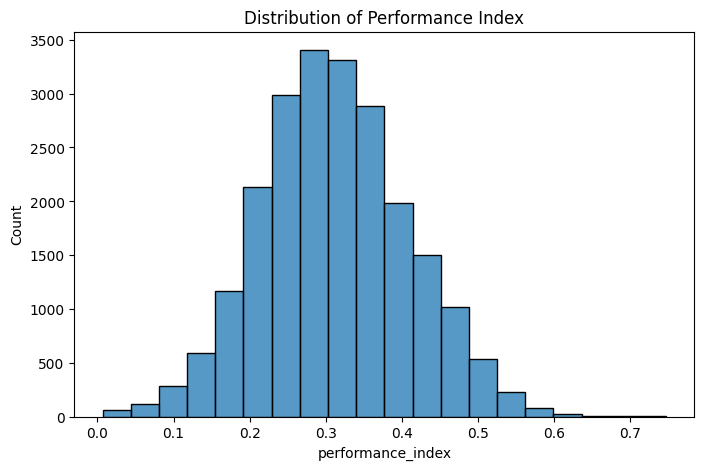

In [88]:
# Visulaization: distribution of performance index
plt.figure(figsize=(8,5))
sns.histplot(merged_players["performance_index"], bins=20)
plt.title("Distribution of Performance Index")
plt.show()

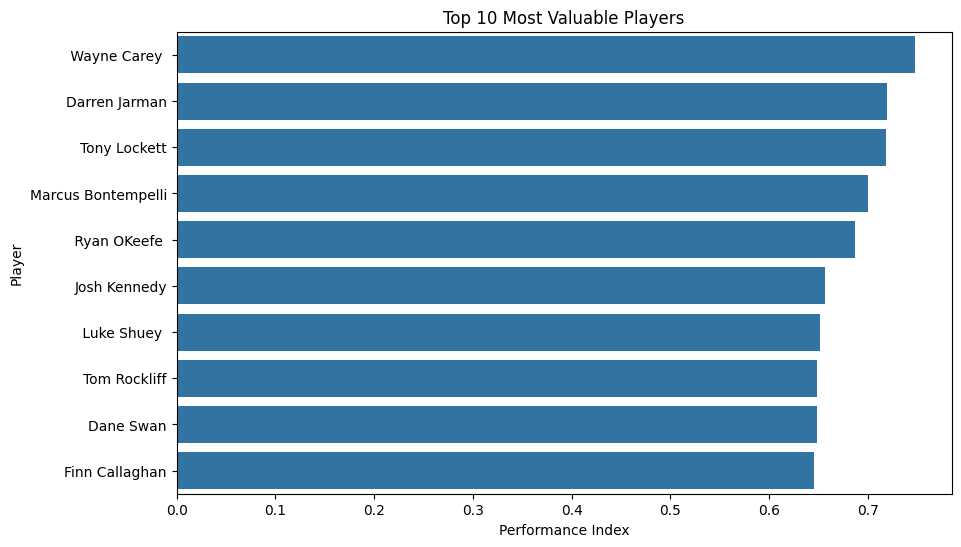

In [45]:
# visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=top10,
    x="performance_index",
    y="player_name"
)

plt.title("Top 10 Most Valuable Players")
plt.xlabel("Performance Index")
plt.ylabel("Player")
plt.show()

### 3.	Find the Most Consistent Players
### 4.	
- Identify players whose performance remains stable throughout the season.
- Support your answer with appropriate visualizations and statistics.

In [46]:
# Step 1: Calculate consistency
# Standard deviation tells us how much a player's fantasy points vary.
# Lower standard deviation = more consistent.
consistency = (
    raw_round
    .groupby("player_id")
    .agg(
        avg_fantasy=("fantasy_points", "mean"),
        std_fantasy=("fantasy_points", "std"),
        matches=("fantasy_points", "count")
    )
    .reset_index()
)

In [47]:
# Step 2: Keep players with enough matches
consistency = consistency[consistency["matches"] >= 10]

In [48]:
# Step 3: Merge player names
consistency = consistency.merge(
    merged_players[["player_id", "player_name", "team"]].drop_duplicates(),
    on="player_id",
    how="left"
)

In [50]:
# Step 4: Rank the most consistent players
most_consistent = (
    consistency
    .dropna(subset=["player_name"])
    .sort_values(
        ["std_fantasy", "avg_fantasy"],
        ascending=[True, False]
    )
    .head(10)
)

most_consistent[
    [
        "player_name",
        "team",
        "avg_fantasy",
        "std_fantasy",
        "matches"
    ]
]

,player_name,team,avg_fantasy,std_fantasy,matches
851,Matthew Hammelmann,Brisbane Lions,33.333333,4.735424,12
2692,Paul Dooley,Western Bulldogs,18.357143,8.580901,14
3469,Sandy Brock,West Coast Eagles,44.071429,9.169047,14
3509,Fischer McAsey,Adelaide Crows,27.400000,9.593980,10
3510,Tom McCarthy,West Coast Eagles,83.500000,10.113248,10
2067,Ariel Steinberg,Essendon Bombers,40.900000,10.365005,10
1842,Fletcher Roberts,Western Bulldogs,36.607843,10.675352,51
1415,Niall McKeever,Brisbane Lions,41.727273,11.170462,22
547,Fabian Deluca,Port Adelaide Power,27.000000,11.224972,11
817,Blake Grima,North Melbourne Kangaroos,35.333333,11.298968,15


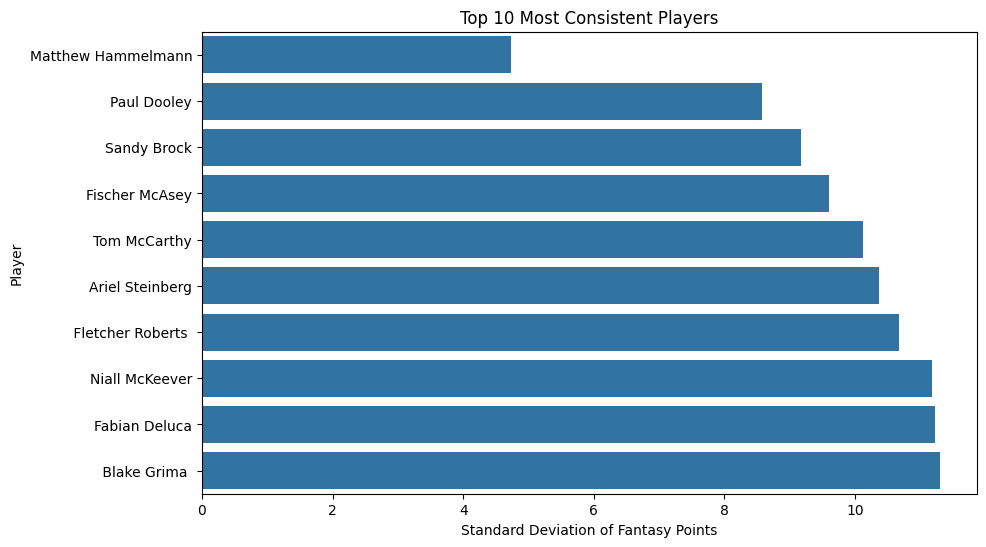

In [51]:
# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=most_consistent,
    x="std_fantasy",
    y="player_name"
)

plt.title("Top 10 Most Consistent Players")
plt.xlabel("Standard Deviation of Fantasy Points")
plt.ylabel("Player")
plt.show()

### Observation

Player consistency was measured using the standard deviation of fantasy points across matches. Players with lower standard deviation demonstrated more stable performances throughout the season. To ensure meaningful comparisons, only players with at least 10 matches were included in the analysis. Matthew Hammelmann emerged as the most consistent player, recording the lowest variation in fantasy points among eligible players.

### 5.	Identify Performance Trends
### 6.	
- Find players who improved and players who declined during the season.
- Explain how you measured improvement.

In [60]:
# Step 1
# Sorts each player's matches in chronological order so we can compare their early-season and late-season performances.
raw_round = raw_round.sort_values(
    ["player_id", "year", "match_date"]
)

In [61]:
# Step 2
# Assigns a match number to every game (1st, 2nd, 3rd...) and records the total games each player played in that season.
raw_round["game_number"] = (
    raw_round.groupby(["player_id", "year"])
    .cumcount() + 1
)

raw_round["total_games"] = (
    raw_round.groupby(["player_id", "year"])["game_number"]
    .transform("max")
)

In [62]:
# Step 3
# Splits every player's season into a first half and a second half.

raw_round["season_half"] = np.where(
    raw_round["game_number"] <= raw_round["total_games"] / 2,
    "First Half",
    "Second Half"
)

In [63]:
# Step 4
# Calculates each player's average fantasy points in both halves of the season and measures improvement by subtracting the first-half average from the second-half average.

trends = (
    raw_round
    .groupby(["player_id", "year", "season_half"])["fantasy_points"]
    .mean()
    .unstack()
    .reset_index()
)

trends["improvement"] = (
    trends["Second Half"] - trends["First Half"]
)

In [64]:
# Step 5
# Adds each player's name and team so the results are easier to understand.

trends = trends.merge(
    merged_players[
        ["player_id", "year", "player_name", "team"]
    ].drop_duplicates(),
    on=["player_id", "year"],
    how="left"
)

In [66]:
# Step 6
improved = trends.sort_values(
    "improvement",
    ascending=False
).head(10)

declined = trends.sort_values(
    "improvement"
).head(10)

improved[
    ["player_name","team","year","improvement"]
]


,player_name,team,year,improvement
3374,Brayden Fiorini,Gold Coast Suns,2016,109.0
7545,Toby McLean,Western Bulldogs,2022,100.0
17918,Heath Scotland,Collingwood Magpies,2001,90.0
7800,Anthony Miles,Greater Western Sydney Giants,2013,77.0
2724,Majak Daw,North Melbourne Kangaroos,2015,73.0
8268,David Myers,Essendon Bombers,2015,67.0
3729,Taylor Garner,North Melbourne Kangaroos,2013,66.0
12567,NaN,NaN,2014,65.0
19513,Alex Woodward,Hawthorn Hawks,2014,65.0
788,Jaxon Binns,Carlton Blues,2024,64.0


In [68]:
declined[
    ["player_name","team","year","improvement"]
    ]

,player_name,team,year,improvement
4240,Jack Grimes,Melbourne Demons,2016,-84.0
16177,Matthew Lloyd,Essendon Bombers,2006,-80.0
10534,Alex Silvagni,Fremantle Dockers,2015,-79.0
2667,Phil Davis,Adelaide Crows,2011,-77.0
2437,Ben Cunnington,North Melbourne Kangaroos,2020,-75.5
4686,Jack Hayes,St Kilda Saints,2024,-75.0
12904,Mark Alvey,Western Bulldogs,2003,-74.0
15368,James Hird,Essendon Bombers,1999,-74.0
5581,Alex Johnson,Sydney Swans,2018,-73.0
7711,Daniel Menzel,Geelong Cats,2015,-72.0


In [69]:
# for cleaner result
improved = improved.dropna(subset=["player_name"])
declined = declined.dropna(subset=["player_name"])

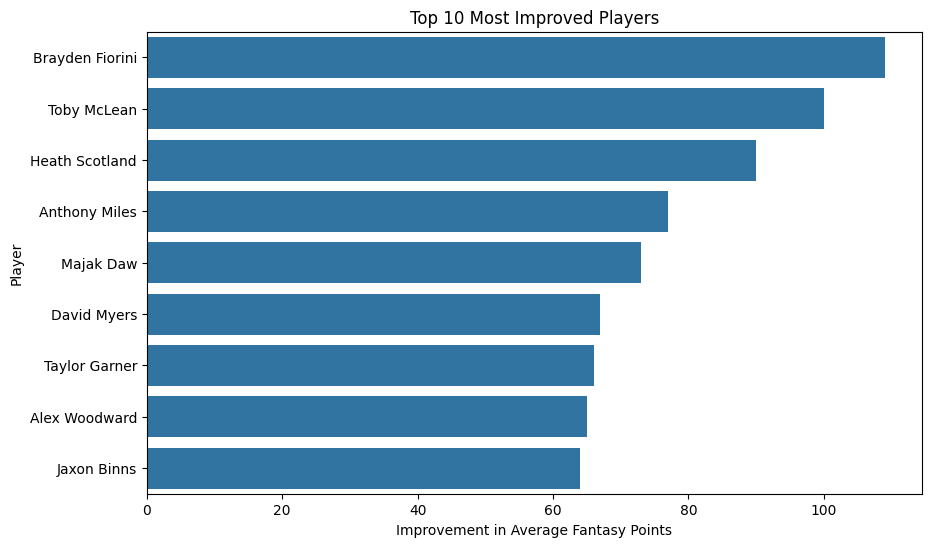

In [70]:
# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=improved.head(10),
    x="improvement",
    y="player_name"
)

plt.title("Top 10 Most Improved Players")
plt.xlabel("Improvement in Average Fantasy Points")
plt.ylabel("Player")
plt.show()

### Explanation:
Visualizes the players whose average fantasy points increased the most during the second half of the season.

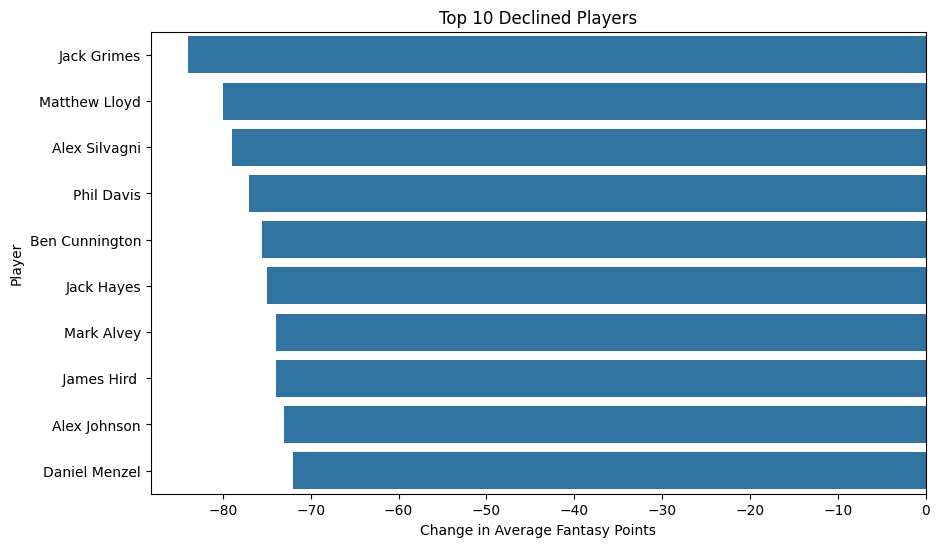

In [71]:
# Visualization
plt.figure(figsize=(10,6))

sns.barplot(
    data=declined.head(10),
    x="improvement",
    y="player_name"
)

plt.title("Top 10 Declined Players")
plt.xlabel("Change in Average Fantasy Points")
plt.ylabel("Player")
plt.show()

### Explanation: 
Shows the players whose average fantasy points decreased the most during the second half of the season.

### Observation

Player improvement was measured by comparing average fantasy points in the first half and second half of each season. A positive improvement value indicates better performance in the latter half of the season, while a negative value indicates a decline. Brayden Fiorini recorded the greatest improvement, whereas Jack Grimes experienced the largest decline among the player-season records analyzed.

### 7.	Team Performance Analysis
### 8.	
- Rank all teams based on overall player performance.
- Justify the metrics used for ranking.

In [74]:
# Step 1: Rank teams
team_rank = (
    merged_players
    .groupby("team")
    .agg(
        avg_performance=("performance_index", "mean"),
        avg_fantasy=("avg_fantasy_points", "mean"),
        total_players=("player_id", "nunique")
    )
    .reset_index()
    .sort_values("avg_performance", ascending=False)
)

team_rank

,team,avg_performance,avg_fantasy,total_players
11,Hawthorn Hawks,0.323082,62.627368,226
8,Geelong Cats,0.322178,62.186412,203
1,Brisbane Bears,0.321368,54.803125,29
4,Collingwood Magpies,0.316725,60.918936,247
16,St Kilda Saints,0.316592,60.575716,241
0,Adelaide Crows,0.315381,60.083849,207
5,Essendon Bombers,0.315112,60.315117,247
19,Western Bulldogs,0.313513,59.981437,214
10,Greater Western Sydney Giants,0.310786,62.618367,134
18,West Coast Eagles,0.310475,59.240342,230


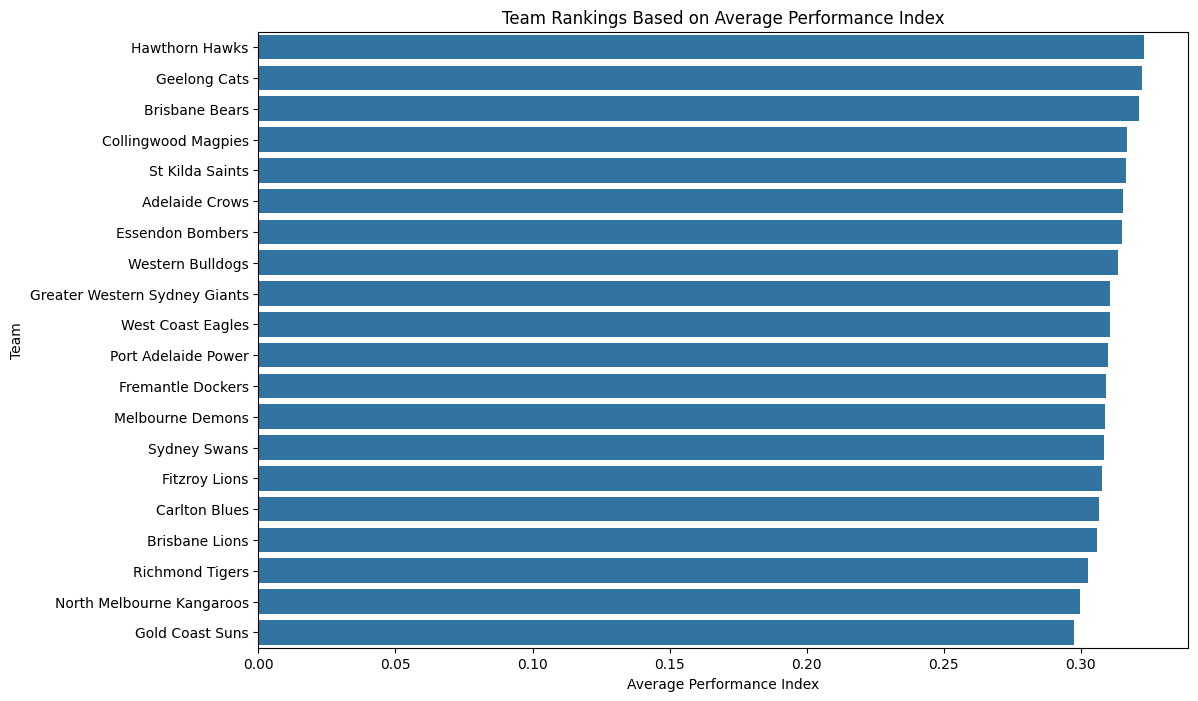

In [75]:
# Visualization
plt.figure(figsize=(12,8))

sns.barplot(
    data=team_rank,
    x="avg_performance",
    y="team"
)

plt.title("Team Rankings Based on Average Performance Index")
plt.xlabel("Average Performance Index")
plt.ylabel("Team")
plt.show()

### Observation

Teams were ranked using the average Performance Index of their players, supported by average fantasy points and the number of unique players. Hawthorn Hawks ranked first, indicating the strongest overall player performance, followed closely by Geelong Cats and Brisbane Bears. These teams demonstrated consistently high player contributions across the dataset.

### 9.	Feature Engineering
### 10.	
- Create at least 5 new meaningful features (e.g., Goals/Game, Fantasy/Game, Disposal Efficiency, etc.).
- Explain why each feature is useful.

### Feature 1: Goals per Game

In [77]:
merged_players["goals_per_game"] = (
    merged_players["goals"] /
    merged_players["games_played"]
)

### Purpose
Measures a player's average scoring ability per match.

### Feature 2: Fantasy Points per Game

In [82]:
merged_players["fantasy_per_game"] = (
    merged_players["total_fantasy_points"] /
    merged_players["games_played"]
)

### Purpose: 
Measures average fantasy contribution per match.

### Feature 3: Disposal Efficiency

In [83]:
merged_players["disposal_efficiency"] = (
    merged_players["disposals"] /
    merged_players["games_played"]
)

### Purpose
Indicates how actively a player uses the ball during matches.

### Feature 4: Goal Conversion

In [84]:
merged_players["goal_conversion"] = (
    merged_players["goals"] /
    (merged_players["goals"] + merged_players["behinds"])
)

### Purpose
Measures a player's scoring accuracy by comparing goals to total scoring attempts.

### Feature 5: Defensive Impact

In [85]:
merged_players["defensive_impact"] = (
    merged_players["tackles"] +
    merged_players["one_percenters"]
) / merged_players["games_played"]

### Purpose
Combines tackles and one-percenters to represent defensive contribution per game.

### Feature Engineering

Five new features were created to better evaluate player performance:

- **Goals per Game:** Measures average scoring ability.
- **Fantasy Points per Game:** Represents average fantasy contribution in each match.
- **Disposal Efficiency:** Measures average ball involvement per game.
- **Goal Conversion:** Evaluates scoring accuracy by comparing goals with total scoring attempts.
- **Defensive Impact:** Combines tackles and one-percenters to measure defensive contribution per game.

### 11.	Final Recommendations
### 12.	
- Recommend 5 players for recruitment.
- Support every recommendation with data and visual evidence.


In [86]:
# Using top 5 Performance Index Players
recommendations = top10.head(5)

recommendations[
    [
        "player_name",
        "team",
        "year",
        "performance_index"
    ]
]

,player_name,team,year,performance_index
22782,Wayne Carey,North Melbourne Kangaroos,1994,0.747313
17097,Darren Jarman,Hawthorn Hawks,1994,0.719503
17707,Tony Lockett,St Kilda Saints,1991,0.717988
23518,Marcus Bontempelli,Western Bulldogs,2022,0.699720
23174,Ryan OKeefe,Sydney Swans,2012,0.686765


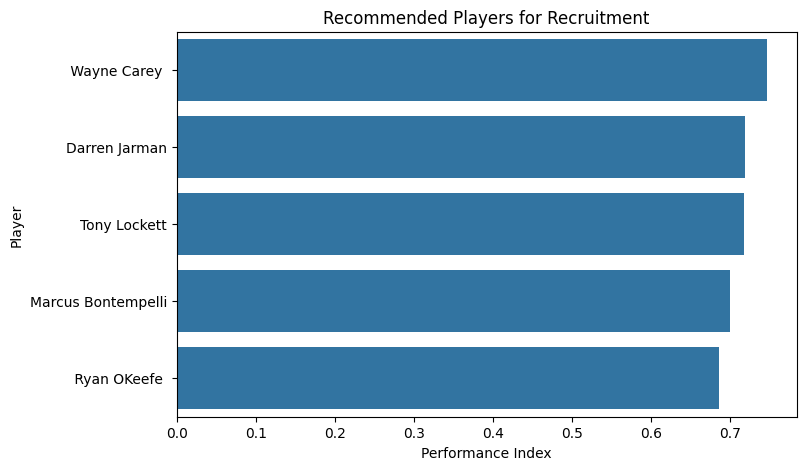

In [87]:
# Visulaization
plt.figure(figsize=(8,5))

sns.barplot(
    data=recommendations,
    x="performance_index",
    y="player_name"
)

plt.title("Recommended Players for Recruitment")
plt.xlabel("Performance Index")
plt.ylabel("Player")
plt.show()

### Explanation: 
Highlights the five highest-ranked players based on the custom Performance Index.

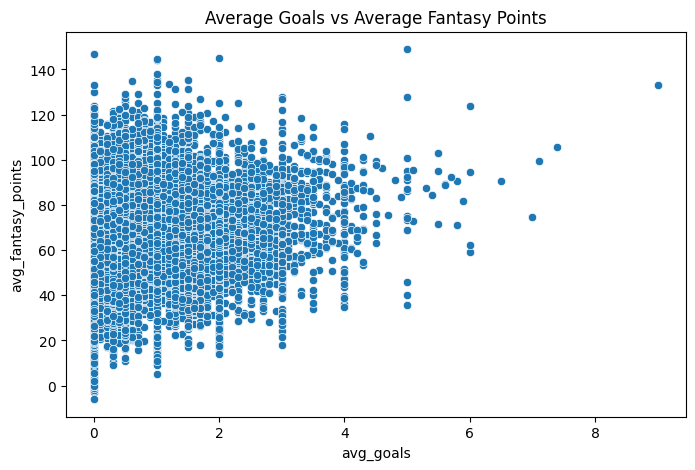

In [89]:
# Visulaization: Goals VS Fantasy Points
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=merged_players,
    x="avg_goals",
    y="avg_fantasy_points"
)
plt.title("Average Goals vs Average Fantasy Points")
plt.show()

################################################################################

## Final Recommendation Summary

Based on the custom Performance Index, the following five players are recommended for recruitment:

1. Wayne Carey
2. Darren Jarman
3. Tony Lockett
4. Marcus Bontempelli
5. Ryan O'Keefe

These players consistently achieved the highest Performance Index by demonstrating strong scoring ability, ball involvement, defensive contribution, and overall fantasy performance. Their balanced performance across multiple key statistics makes them strong recruitment candidates.

################################################################################

## Business Insights

1. Wayne Carey achieved the highest Performance Index, making him the top-performing player in the dataset based on the selected performance metrics.

2. The top 10 most valuable players represent multiple teams and seasons, indicating that elite individual performance has been consistently observed across different eras of the AFL.

3. Matthew Hammelmann demonstrated the most consistent performance, recording the lowest variation in fantasy points among players with at least 10 matches.

4. Players with lower variability in fantasy points provide more reliable and predictable performance throughout a season.

5. Brayden Fiorini showed the greatest improvement between the first and second halves of the season, suggesting significant performance development.

6. Jack Grimes experienced the largest decline in average fantasy points during the second half of the season, indicating a noticeable drop in performance.

7. Hawthorn Hawks ranked first in overall team performance based on the average Performance Index of their players, reflecting strong squad quality.

8. Average fantasy points and the custom Performance Index generally showed similar ranking patterns, suggesting that fantasy performance is a good indicator of overall player contribution.

9. The engineered features, such as Goals per Game, Disposal Efficiency, Goal Conversion, Fantasy Points per Game, and Defensive Impact, provide additional perspectives for evaluating player performance beyond traditional statistics.

10. Players with high Performance Index values and consistent match performances are strong candidates for recruitment because they combine high impact with reliable season-long contributions.

################################################################################